# Pipeline de Treinamento de Modelos para Detecção de Livros em Imagens

## 1. Introdução

O objetivo deste pipeline é treinar modelos clássicos de machine learning para **detectar o objeto livro** em imagens.<br> 
A saída dos modelos são caixas delimitadoras (indicando a localização do livro) e pontuações de confiança.

### Prova de Conceito (POC)

A **POC deste trabalho é a aplicação Streamlit**, implementada em `src/app/`. Ela recebe uma imagem enviada pelo usuário, executa os modelos salvos de Regressão Logística e MLP e exibe as caixas previstas por cada modelo, com os respectivos limiares e resultados independentes.

Este notebook apresenta a metodologia, o treinamento e a avaliação; o Streamlit permite a **demonstração prática do pipeline em uma imagem nova ou previamente obtida**. A demonstração não substitui as métricas de avaliação nem garante bom desempenho em outras imagens.

Para executar a POC, abra um terminal na raiz do projeto:

```powershell
uv run streamlit run src/app/main.py
```

No navegador, envie uma imagem e clique em **Comparar todos os modelos**. Os modelos precisam estar salvos em `models/`; a POC não repete o treinamento.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from threadpoolctl import threadpool_limits

from src.detection.classifiers import train_classifier
from src.detection.hard_negatives import mine_hard_negatives
from src.detection.hog_detector import detect_many, training_features
from src.evaluation.detection import DetectionMetrics, candidate_coverage, count_matches
from src.evaluation.run_logistic import report_progress
from src.evaluation.run_precision import LOGISTIC_THRESHOLDS, MLP_THRESHOLDS
from src.evaluation.test_set import evaluate_test_models, report_test_progress
from src.evaluation.thresholds import (
    ThresholdResult,
    evaluate_models_thresholds,
    load_threshold_report,
    save_threshold_report,
    select_threshold,
)
from src.utils.coco import load_coco_split
from src.utils.geometry import clip_box
from src.utils.model_io import load_model, save_model
from src.utils.path import EVALUATION_DIR
from src.utils.presentation import (
    comparison_figure,
    dataset_gallery,
    detection_figure,
    export_figure,
    latest_manifest,
    preprocessing_figure,
    table,
    threshold_figure,
    validation_test_figure,
)

cv2.setNumThreads(1)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

# False = apresentação rápida; True = novos experimentos deliberados.
RETRAIN_MODELS = False
REEVALUATE_VALIDATION = False
IOU_THRESHOLD = 0.5
MINIMUM_RECALL = 0.5
SEED = 42
NEGATIVES_PER_IMAGE = 30

figures = {}
models = {}
manifest = latest_manifest()
stored_entries = {entry["label"]: entry for entry in manifest["experiments"]}
print("Modo:", "novo treinamento" if RETRAIN_MODELS else "modelos e resultados salvos")
print("Dados de validação do experimento:", manifest["images"], "imagens")

Modo: modelos e resultados salvos
Dados de validação do experimento: 45 imagens


### Como uma imagem se torna uma detecção?

`Imagem → normalização espacial → janelas multiescala → HOG → classificador → limiar → NMS → caixas`

- A imagem completa mantém sua proporção, com o maior lado em **640 pixels**.
- As janelas têm tamanhos estimados nas caixas de **train** e procuram livros em diferentes posições e escalas.
- Cada recorte vira um vetor **HOG com 5.940 valores**. O classificador recebe esse vetor, não a imagem crua.
- O limiar descarta janelas de baixa pontuação. O **NMS** remove detecções redundantes com IoU ≥ 0,35.
- As caixas finais voltam às coordenadas da imagem original.

**Distinção importante:** o classificador aprende “livro ou fundo” por recorte; a varredura de janelas é responsável pela localização.

## 2. Descrição dos dados

O conjunto de dados foi adquirido a partir do repositório https://universe.roboflow.com/hifsaiftikhar77-gmail-com/day-24-book-detection.<br>
O dataset é composto por imagens e anotações **COCO** da categoria `Book`.

In [2]:
train_records = load_coco_split("train")
valid_records = load_coco_split("valid")
test_records = load_coco_split("test")
splits = {"train": train_records, "valid": valid_records, "test": test_records}

display(
    table(
        ["Divisão", "Imagens", "Livros anotados", "Imagens sem livro anotado", "Papel"],
        [
            [
                split,
                len(records),
                sum(len(record.annotations) for record in records),
                sum(not record.annotations for record in records),
                {"train": "Aprendizado", "valid": "Ajustes", "test": "Avaliação final"}[split],
            ]
            for split, records in splits.items()
        ],
    )
)

Divisão,Imagens,Livros anotados,Imagens sem livro anotado,Papel
train,156,204,40,Aprendizado
valid,45,77,2,Ajustes
test,22,37,0,Avaliação final


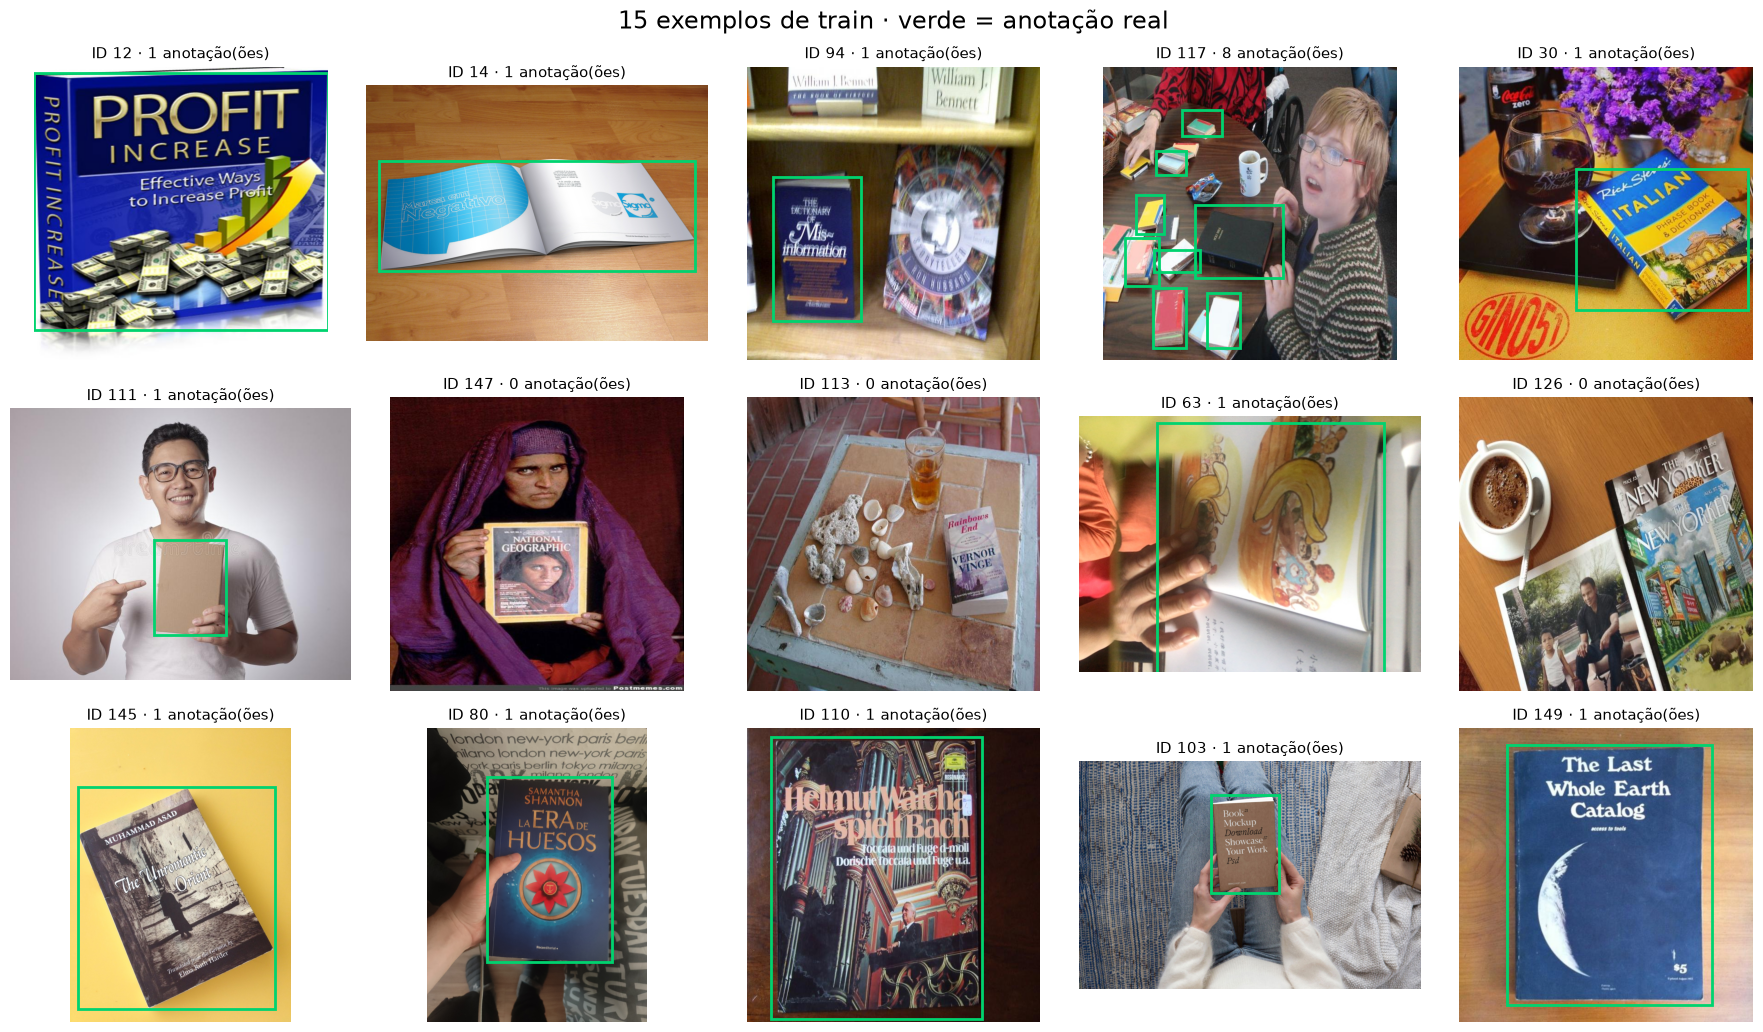

In [3]:
figures["dados_15_exemplos"] = dataset_gallery(train_records, count=15, seed=SEED)
plt.show()

Alguns imagens contém mais de um livro identificado. Ter mais de um livro por imagem faz diferença: as métricas de detecção contam **objetos e caixas**, não apenas imagens classificadas como positivas.

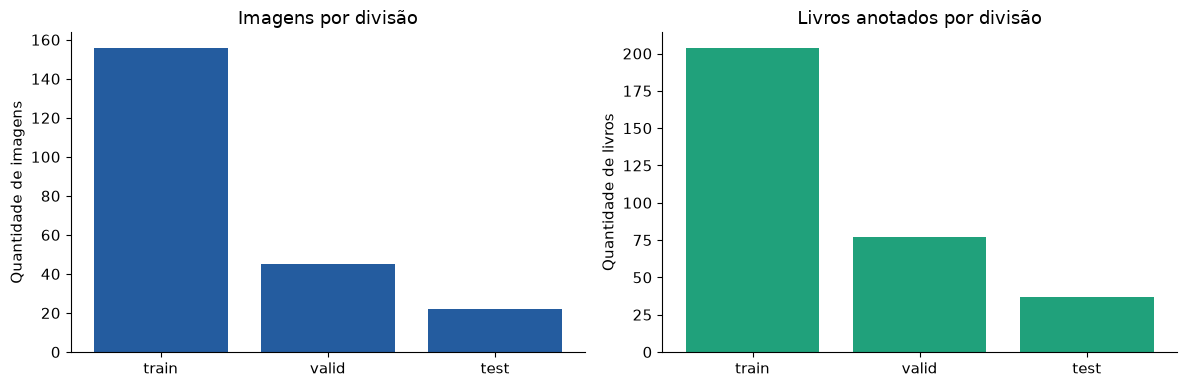

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(splits)
axes[0].bar(names, [len(records) for records in splits.values()], color="#245c9f")
axes[0].set(title="Imagens por divisão", ylabel="Quantidade de imagens")
axes[1].bar(
    names,
    [sum(len(record.annotations) for record in records) for records in splits.values()],
    color="#20a17b",
)
axes[1].set(title="Livros anotados por divisão", ylabel="Quantidade de livros")
figure.tight_layout()
figures["distribuicao_dataset"] = figure
plt.show()

## 3. Pré-processamento

As etapas abaixo compõem o protocolo atual.

| Etapa | Finalidade | Limitação |
| --- | --- | --- |
| Normalização espacial | Padronizar a escala de busca e reduzir o custo | Pode perder detalhes pequenos |
| Escala de cinza | Descrever intensidades em um canal | Descarta a cor da capa |
| CLAHE | Realçar contraste local | Também pode realçar textura de fundo |
| Recorte em 96 × 128 | Garantir descritores de tamanho fixo | Deforma proporções dos recortes |
| HOG | Representar contornos e orientações de gradiente | Não entende o significado do objeto |
| StandardScaler | Padronizar cada característica para os modelos | Deve ser ajustado somente em train |

O HOG usa células 8 × 8, blocos 16 × 16, passo 8 × 8 e nove orientações. O resultado é um vetor de **5.940 características**.

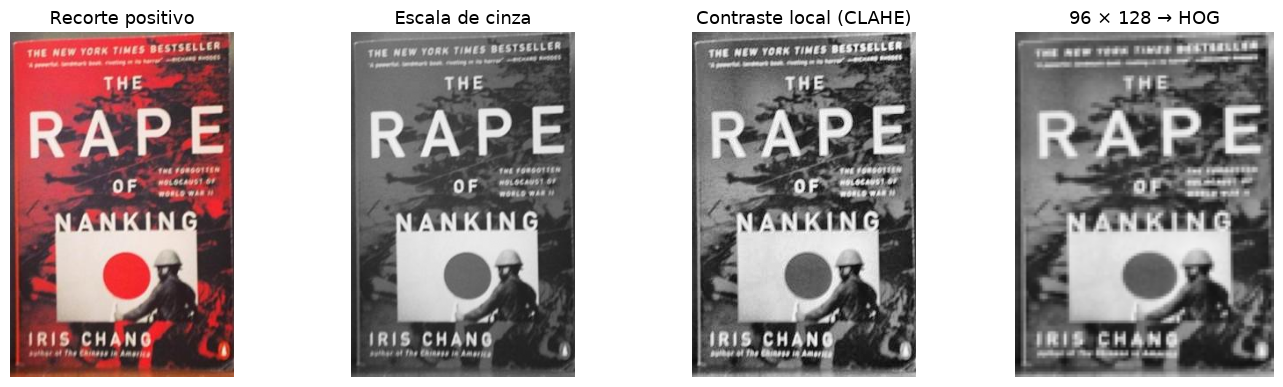

In [5]:
example_record = next(record for record in train_records if record.annotations)
figures["preprocessamento"] = preprocessing_figure(example_record)
plt.show()

## 4. Treinamento dos modelos

Foram treinados os modelos de **Regressão Logística e MLP**. Ambos usam HOG e StandardScaler. Nenhuma imagem de valid ou test entra na geração dos exemplos de treinamento.

### 4.1. Exemplos positivos e negativos

- **Positivos (rótulo 1):** recortes das caixas reais e até duas janelas extras por livro com IoU ≥ 0,60.
- **Negativos aleatórios (rótulo 0):** até 30 janelas por imagem, com ocupação anotada total ≤ 1%.
- **Negativos difíceis:** até oito fundos de alta pontuação por imagem, após NMS, em 30 imagens de train escolhidas com semente 42. A mesma regra de ocupação impede que fragmentos anotados de livros sejam tratados como fundo.
- **Entrada:** matriz `(N, 5940)`; **saída esperada:** vetor `(N,)` com zeros e uns.

A ocupação considera quanto da janela é preenchido por livros anotados. Só usar IoU baixa seria incorreto: uma janela pequena inteiramente dentro de um livro grande também tem IoU baixa.

O experimento com negativos difíceis mantém C=1. O experimento de regularização usa C=0,01 e os mesmos recortes aleatórios da referência. Assim, são duas hipóteses testadas separadamente.

In [6]:
baseline_label = "Regressão — 30 negativos"
baseline_saved = load_model(stored_entries[baseline_label]["model"])
detector_config = baseline_saved.detector_config_

if RETRAIN_MODELS:
    with threadpool_limits(limits=2):
        train_features, train_labels = training_features(
            train_records,
            negatives_per_image=NEGATIVES_PER_IMAGE,
            seed=SEED,
            config=detector_config,
        )
    print("Entrada HOG:", train_features.shape)
    print("Positivos:", int((train_labels == 1).sum()))
    print("Negativos aleatórios:", int((train_labels == 0).sum()))
else:
    print("Preparação já realizada no experimento salvo; não extraímos HOG novamente.")
    display(
        table(
            ["Experimento", "Recortes de treino", "Negativos difíceis", "C da regressão"],
            [
                [
                    entry["label"],
                    entry["metadata"]["samples"],
                    entry["metadata"]["hard_negatives"],
                    "Não se aplica"
                    if entry["label"].startswith("MLP")
                    else entry["metadata"]["regularization_c"],
                ]
                for entry in manifest["experiments"]
            ],
        )
    )

Preparação já realizada no experimento salvo; não extraímos HOG novamente.


Experimento,Recortes de treino,Negativos difíceis,C da regressão
Regressão — 30 negativos,4885,0,1.0
"Regressão — C=0,01",4885,0,0.01
Regressão — negativos difíceis,5057,172,1.0
MLP — 30 negativos,4885,0,Não se aplica


### 4.2. Regressão Logística — referência

É um classificador linear rápido e interpretável, adequado como referência para HOG. Aprende pesos para distinguir livro de fundo, com `class_weight="balanced"`, C=1 e até 3.000 iterações.

A pontuação utilizada na detecção é a **margem de decisão**, não uma probabilidade. Um limiar positivo mais alto exige maior evidência para aceitar a janela.

In [7]:
if RETRAIN_MODELS:
    with threadpool_limits(limits=2):
        models[baseline_label] = train_classifier(
            "logistic_regression", train_features, train_labels, detector_config
        )
else:
    models[baseline_label] = baseline_saved

logistic_model = models[baseline_label]
print("Referência pronta:", stored_entries[baseline_label]["model"])

Referência pronta: logistic_regression_003


### 4.3. Regressão Logística — regularização mais forte

C é o inverso da força de regularização. **C=0,01** penaliza mais os pesos que C=1, buscando reduzir o ajuste excessivo a detalhes dos recortes de treino. Isso é uma hipótese, não uma garantia de melhoria.

A amostra, o HOG, as janelas, a semente e o balanceamento permanecem iguais à referência.

In [8]:
regularized_label = "Regressão — C=0,01"
if RETRAIN_MODELS:
    with threadpool_limits(limits=2):
        models[regularized_label] = train_classifier(
            "logistic_regression",
            train_features,
            train_labels,
            detector_config,
            regularization=0.01,
        )
else:
    models[regularized_label] = load_model(stored_entries[regularized_label]["model"])
print("Variante com regularização pronta.")

Variante com regularização pronta.


### 4.4. Regressão Logística — negativos difíceis

A referência pode acertar fundos fáceis e continuar produzindo falsos alarmes em regiões com bordas e textura. A mineração seleciona **erros reais da referência em train**, adiciona esses recortes como negativos e faz um novo treinamento.

A mineração depende de anotações completas: um livro não anotado pode ser confundido com fundo.

In [9]:
hard_label = "Regressão — negativos difíceis"
if RETRAIN_MODELS:
    with threadpool_limits(limits=2):
        mined = mine_hard_negatives(
            train_records,
            logistic_model,
            max_images=30,
            per_image=8,
            seed=SEED,
            progress=report_progress,
        )
        augmented_features = np.concatenate([train_features, mined.features])
        augmented_labels = np.concatenate(
            [train_labels, np.zeros(len(mined.features), dtype=np.int32)]
        )
        models[hard_label] = train_classifier(
            "logistic_regression", augmented_features, augmented_labels, detector_config
        )
    print("Negativos difíceis adicionados:", len(mined.features))
else:
    models[hard_label] = load_model(stored_entries[hard_label]["model"])
    print(
        "Negativos difíceis adicionados:", stored_entries[hard_label]["metadata"]["hard_negatives"]
    )

Negativos difíceis adicionados: 172


### 4.5. MLP

O MLP aprende relações não lineares entre as características HOG. Usa duas camadas ocultas de **128 e 64 neurônios**, até 1.000 épocas e parada antecipada.

Recebe os mesmos recortes aleatórios da regressão de referência, sem os negativos difíceis. A validação interna do early stopping usa 10% dos recortes de train; recortes relacionados podem estar dos dois lados dessa divisão interna. Por isso, seu escore interno não substitui a avaliação de detecção na pasta valid.

A pontuação na detecção é `p(livro) − 0,5`. Seus limiares precisam de uma grade própria.

In [10]:
mlp_label = "MLP — 30 negativos"
if RETRAIN_MODELS:
    with threadpool_limits(limits=2):
        models[mlp_label] = train_classifier("mlp", train_features, train_labels, detector_config)
else:
    models[mlp_label] = load_model(stored_entries[mlp_label]["model"])

mlp_model = models[mlp_label]
print("Épocas efetivamente executadas:", mlp_model["model"].n_iter_)

Épocas efetivamente executadas: 19


## 5. Validação dos modelos e escolha dos limiares

### 5.1. O que conta como acerto?

Uma previsão é um **TP** quando corresponde a um livro anotado com **IoU ≥ 0,50**, em correspondência um-a-um e ordem decrescente de pontuação.

- **TP:** livro corretamente localizado.
- **FP:** caixa sem correspondência válida; pode ser fundo, localização imprecisa ou detecção duplicada.
- **FN:** livro real sem correspondência.
- **Precisão:** TP / (TP + FP).
- **Recall (revocação):** TP / (TP + FN).
- **F1:** média harmônica entre precisão e recall.

Aumentar o limiar costuma reduzir FP, mas pode perder livros. Escolhemos a **maior precisão entre os limiares com recall ≥ 50%**, com desempate por F1 e menor limiar.

### 5.2. Grades adequadas às pontuações de cada modelo

Na regressão, ampliamos a grade até 25. No MLP, testamos limiares de 0 a 0,499, equivalentes a probabilidades mínimas de 50% a 99,9%.

A extração HOG é compartilhada entre os modelos com as mesmas janelas. Cada imagem de valid é percorrida uma vez; todas as grades reutilizam as pontuações. Os testes verificam equivalência com avaliações independentes. Isso economiza tempo sem alterar o protocolo.

In [11]:
threshold_grades = {
    name: MLP_THRESHOLDS if name.startswith("MLP") else LOGISTIC_THRESHOLDS for name in models
}
display(
    table(
        ["Classificador", "Limiares avaliados"],
        [
            ["Regressão Logística", ", ".join(f"{value:g}" for value in LOGISTIC_THRESHOLDS)],
            ["MLP: p(livro) − 0,5", ", ".join(f"{value:g}" for value in MLP_THRESHOLDS)],
        ],
    )
)

if RETRAIN_MODELS or REEVALUATE_VALIDATION:
    with threadpool_limits(limits=2):
        reports = evaluate_models_thresholds(
            valid_records, models, threshold_grades, IOU_THRESHOLD, report_progress
        )
else:
    reports = {
        name: load_threshold_report(EVALUATION_DIR / entry["report"])
        for name, entry in stored_entries.items()
    }
    print("Tabelas completas carregadas dos CSVs; sem nova varredura.")

Classificador,Limiares avaliados
Regressão Logística,"0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25"
"MLP: p(livro) − 0,5","0, 0.1, 0.2, 0.3, 0.4, 0.45, 0.48, 0.49, 0.495, 0.499"


Tabelas completas carregadas dos CSVs; sem nova varredura.


In [12]:
selections = {}
for name, results in reports.items():
    try:
        selections[name] = select_threshold(results, MINIMUM_RECALL)
    except ValueError as error:
        selections[name] = None
        display(Markdown(f"**{name}:** {error}"))
    display(Markdown(f"#### {name}"))
    display(
        table(
            ["Limiar", "TP", "FP", "FN", "Precisão", "Recall", "F1", "Selecionado"],
            [
                [
                    f"{item.threshold:g}",
                    item.metrics.true_positives,
                    item.metrics.false_positives,
                    item.metrics.false_negatives,
                    f"{item.metrics.precision:.2%}",
                    f"{item.metrics.recall:.2%}",
                    f"{item.metrics.f1_score:.4f}",
                    "✓" if item == selections[name] else "",
                ]
                for item in results
            ],
        )
    )

#### Regressão — 30 negativos

Limiar,TP,FP,FN,Precisão,Recall,F1,Selecionado
0,49,7013,28,0.69%,63.64%,0.0137,
0.5,49,6436,28,0.76%,63.64%,0.0149,
1,49,5909,28,0.82%,63.64%,0.0162,
2,48,4958,29,0.96%,62.34%,0.0189,
3,45,4132,32,1.08%,58.44%,0.0212,
4,43,3398,34,1.25%,55.84%,0.0244,
6,42,2274,35,1.81%,54.55%,0.0351,
8,41,1466,36,2.72%,53.25%,0.0518,
10,40,896,37,4.27%,51.95%,0.0790,✓
12,35,537,42,6.12%,45.45%,0.1079,


#### Regressão — C=0,01

Limiar,TP,FP,FN,Precisão,Recall,F1,Selecionado
0,54,6472,23,0.83%,70.13%,0.0164,
0.5,53,5646,24,0.93%,68.83%,0.0184,
1,50,4914,27,1.01%,64.94%,0.0198,
2,47,3638,30,1.28%,61.04%,0.0250,
3,43,2635,34,1.61%,55.84%,0.0312,
4,39,1820,38,2.10%,50.65%,0.0403,
6,39,780,38,4.76%,50.65%,0.0871,✓
8,28,305,49,8.41%,36.36%,0.1366,
10,19,102,58,15.70%,24.68%,0.1919,
12,9,29,68,23.68%,11.69%,0.1565,


#### Regressão — negativos difíceis

Limiar,TP,FP,FN,Precisão,Recall,F1,Selecionado
0,46,7019,31,0.65%,59.74%,0.0129,
0.5,45,6322,32,0.71%,58.44%,0.0140,
1,45,5666,32,0.79%,58.44%,0.0155,
2,42,4587,35,0.91%,54.55%,0.0178,
3,40,3628,37,1.09%,51.95%,0.0214,
4,39,2843,38,1.35%,50.65%,0.0264,✓
6,35,1694,42,2.02%,45.45%,0.0388,
8,35,971,42,3.48%,45.45%,0.0646,
10,27,515,50,4.98%,35.06%,0.0872,
12,23,245,54,8.58%,29.87%,0.1333,


#### MLP — 30 negativos

Limiar,TP,FP,FN,Precisão,Recall,F1,Selecionado
0,55,3640,22,1.49%,71.43%,0.0292,
0.1,53,3322,24,1.57%,68.83%,0.0307,
0.2,52,2980,25,1.72%,67.53%,0.0335,
0.3,50,2646,27,1.85%,64.94%,0.0361,
0.4,50,2202,27,2.22%,64.94%,0.0429,
0.45,47,1820,30,2.52%,61.04%,0.0484,
0.48,44,1410,33,3.03%,57.14%,0.0575,
0.49,43,1173,34,3.54%,55.84%,0.0665,
0.495,43,948,34,4.34%,55.84%,0.0805,✓
0.499,37,531,40,6.51%,48.05%,0.1147,


### 5.3. Curvas de precisão, recall e falsos positivos

Cada linha tem uma escala de limiar própria. **Não compare o valor numérico do limiar da regressão com o do MLP.** A linha vermelha indica a escolha; a linha pontilhada horizontal indica recall de 50%.

Os pontos pertencem à grade testada. Não há garantia de que o melhor ponto seja um ótimo global. Quando não há previsões, a precisão aparece como zero por convenção do cálculo; isso não significa que uma caixa errada foi emitida.

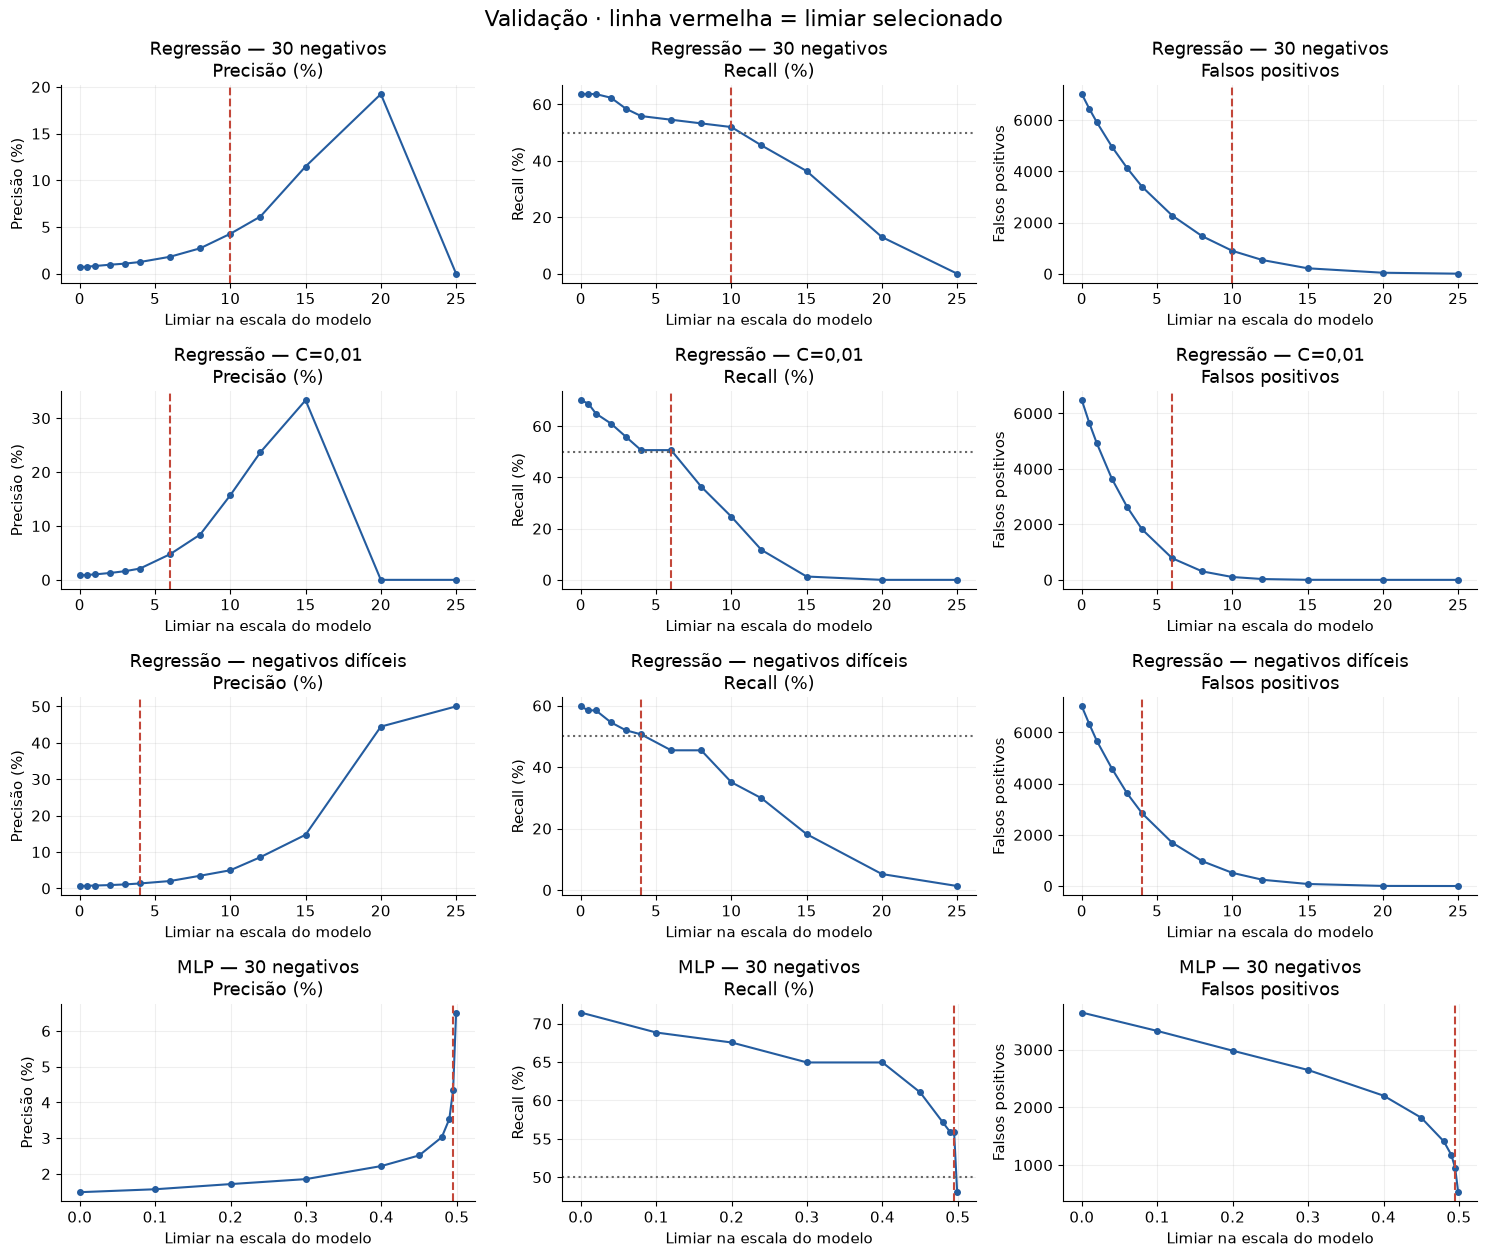

In [13]:
figures["curvas_limiares"] = threshold_figure(reports, selections)
plt.show()

### 5.4. Cobertura geométrica e persistência

A cobertura mede se existe alguma janela capaz de alcançar o livro com IoU suficiente, **independentemente do classificador**. É um limite superior geométrico, não o recall obtido.

Os pickles preservam StandardScaler, classificador, configuração das janelas e limiar escolhido. Novos salvamentos recebem versões e não sobrescrevem os anteriores.

In [14]:
coverage = candidate_coverage(valid_records, detector_config, IOU_THRESHOLD)
print(
    f"Cobertura das janelas: {coverage.covered}/{coverage.total} livros "
    f"({coverage.recall_upper_bound:.1%})"
)

if RETRAIN_MODELS or REEVALUATE_VALIDATION:
    for name, model in models.items():
        selected = selections[name]
        if selected is not None:
            model.score_threshold_ = selected.threshold
        else:
            model.__dict__.pop("score_threshold_", None)
        previous_metadata = dict(getattr(model, "training_metadata_", {}))
        previous_metadata.update(
            {
                "experiment": name,
                "trained_split": "train",
                "threshold_split": "valid",
                "minimum_recall": MINIMUM_RECALL,
                "threshold_selected": selected is not None,
                "seed": SEED,
                "negatives_per_image": NEGATIVES_PER_IMAGE,
            }
        )
        if RETRAIN_MODELS:
            previous_metadata["samples"] = (
                len(augmented_labels) if name == hard_label else len(train_labels)
            )
            previous_metadata["hard_negatives"] = len(mined.features) if name == hard_label else 0
            previous_metadata["regularization_c"] = 0.01 if name == regularized_label else 1.0
            previous_metadata["hard_negative_images"] = (
                list(mined.image_ids) if name == hard_label else []
            )
            previous_metadata["hard_negative_boxes"] = (
                list(mined.source_boxes) if name == hard_label else []
            )
        model.training_metadata_ = previous_metadata
        saved_path = save_model(model, "mlp" if name.startswith("MLP") else "logistic_regression")
        report_path = save_threshold_report(reports[name], saved_path.stem)
        print(saved_path.name, "→", report_path.name)
else:
    print("Nenhum novo pickle criado no modo apresentação.")

Cobertura das janelas: 75/77 livros (97.4%)
Nenhum novo pickle criado no modo apresentação.


## 6. Comparação de métricas e discussão

### 6.1. Comparação com o mesmo critério de escolha

Todos os experimentos abaixo usam as mesmas **45 imagens de valid**, IoU ≥ 0,50 e recall mínimo de 50%. O MLP também teve seu limiar ajustado; não comparamos uma regressão ajustada com um MLP no limiar padrão.

Os resultados são de validação, usados para escolher configurações. **Não são estimativas independentes de generalização em test.**

Experimento,Limiar,Precisão,Recall,F1,TP,FP,FN
Regressão — 30 negativos,10,4.27%,51.95%,0.0790,40,896,37
"Regressão — C=0,01",6,4.76%,50.65%,0.0871,39,780,38
Regressão — negativos difíceis,4,1.35%,50.65%,0.0264,39,2843,38
MLP — 30 negativos,0.495,4.34%,55.84%,0.0805,43,948,34


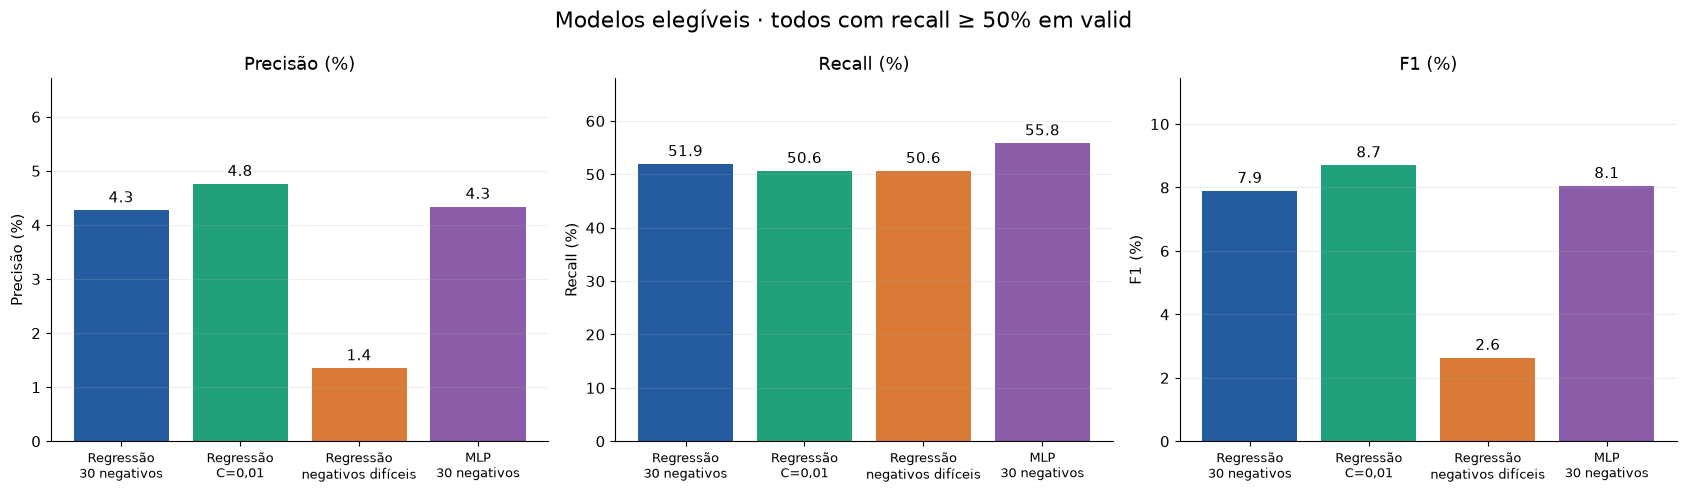

In [15]:
comparison_rows = []
for name, selected in selections.items():
    if selected is None:
        comparison_rows.append([name, "Sem opção elegível", "—", "—", "—", "—", "—", "—"])
        continue
    metrics = selected.metrics
    comparison_rows.append(
        [
            name,
            f"{selected.threshold:g}",
            f"{metrics.precision:.2%}",
            f"{metrics.recall:.2%}",
            f"{metrics.f1_score:.4f}",
            metrics.true_positives,
            metrics.false_positives,
            metrics.false_negatives,
        ]
    )

display(
    table(
        ["Experimento", "Limiar", "Precisão", "Recall", "F1", "TP", "FP", "FN"],
        comparison_rows,
    )
)
figures["comparacao_modelos"] = comparison_figure(selections)
plt.show()

### 6.2. Evolução em relação à etapa anterior

A referência histórica é a regressão com 15 negativos e limiar zero. A tabela permite observar ganhos e perdas reais, sem esconder a queda de recall. “Redução de FP” não significa “aumento equivalente de precisão”.

In [16]:
previous_results = load_threshold_report(EVALUATION_DIR / "logistic_regression_001_thresholds.csv")
historical = next(item for item in previous_results if item.threshold == 0.0)
eligible = {name: item for name, item in selections.items() if item is not None}
winner_name, winner = max(
    eligible.items(), key=lambda pair: (pair[1].metrics.precision, pair[1].metrics.f1_score)
)
recommended_model = models[winner_name]
reduction = 1 - winner.metrics.false_positives / historical.metrics.false_positives
tp_difference = winner.metrics.true_positives - historical.metrics.true_positives

display(
    table(
        ["Configuração", "TP", "FP", "FN", "Precisão", "Recall"],
        [
            [
                "Referência histórica: 15 negativos, limiar 0",
                historical.metrics.true_positives,
                historical.metrics.false_positives,
                historical.metrics.false_negatives,
                f"{historical.metrics.precision:.2%}",
                f"{historical.metrics.recall:.2%}",
            ],
            [
                winner_name,
                winner.metrics.true_positives,
                winner.metrics.false_positives,
                winner.metrics.false_negatives,
                f"{winner.metrics.precision:.2%}",
                f"{winner.metrics.recall:.2%}",
            ],
        ],
    )
)
display(
    Markdown(
        f"**Escolha nesta grade:** {winner_name}, limiar {winner.threshold:g}. "
        f"Redução de FP frente à referência histórica: **{reduction:.1%}**; "
        f"Diferença de TP frente à referência: **{tp_difference:+d}**. "
        f"Precisão final em valid: **{winner.metrics.precision:.2%}**. "
        "A escolha respeita recall mínimo de 50%, mas não elimina as limitações do detector."
    )
)

Configuração,TP,FP,FN,Precisão,Recall
"Referência histórica: 15 negativos, limiar 0",53,8567,24,0.61%,68.83%
"Regressão — C=0,01",39,780,38,4.76%,50.65%


**Escolha nesta grade:** Regressão — C=0,01, limiar 6. Redução de FP frente à referência histórica: **90.9%**; Diferença de TP frente à referência: **-14**. Precisão final em valid: **4.76%**. A escolha respeita recall mínimo de 50%, mas não elimina as limitações do detector.

### 6.3. Exemplos visuais de validação por modelo

Todos os modelos da comparação analisam o **mesmo primeiro registro de valid**, escolhido pela ordem do dataset, não por ter o melhor resultado. Cada modelo usa seu próprio limiar selecionado na seção 5. Todas as caixas previstas são exibidas, sem limitar artificialmente sua quantidade.

A tabela resume os acertos e erros nessa imagem; em seguida, cada experimento tem sua própria figura. À esquerda ficam as anotações reais; à direita, as previsões. A contagem TP/FP/FN considera IoU ≥ 0,50 e correspondência um-a-um. Estes são exemplos qualitativos de uma imagem, não novas métricas agregadas do dataset. Se algum modelo não tiver limiar elegível, o fallback é identificado explicitamente.

**Mesma imagem de valid: ID 11.**

Experimento,Limiar,TP,FP,FN,Caixas
Regressão — 30 negativos,10,1,17,0,18
"Regressão — C=0,01",6,1,15,0,16
Regressão — negativos difíceis,4,1,52,0,53
MLP — 30 negativos,0.495,1,19,0,20


#### Regressão — 30 negativos · limiar 10

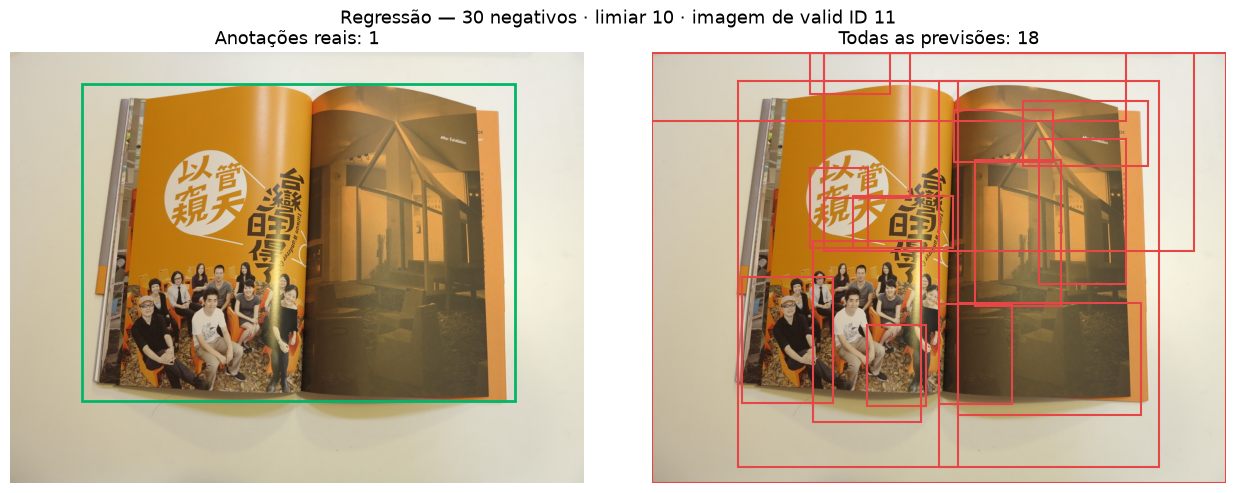

#### Regressão — C=0,01 · limiar 6

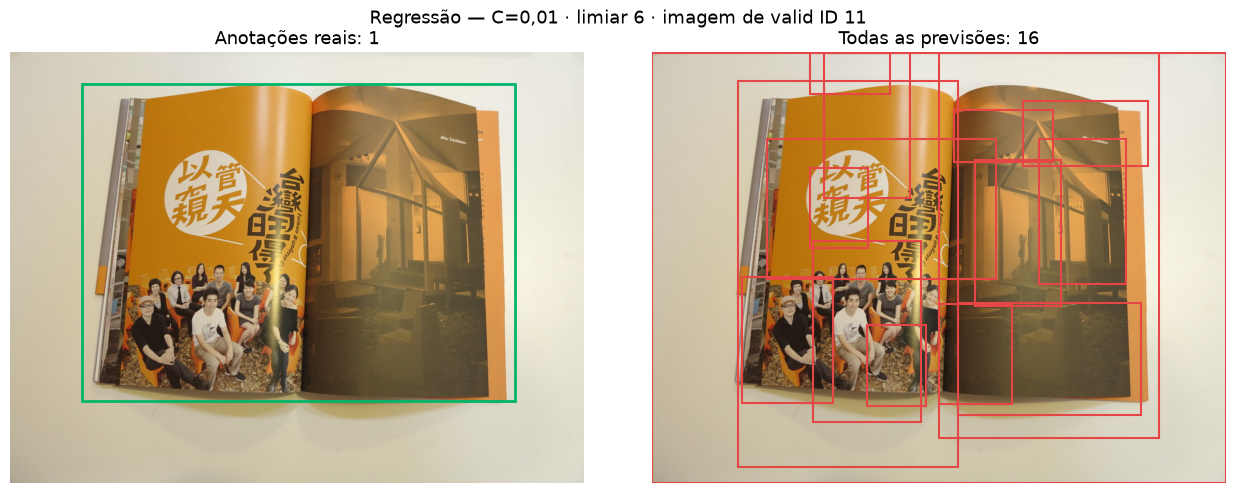

#### Regressão — negativos difíceis · limiar 4

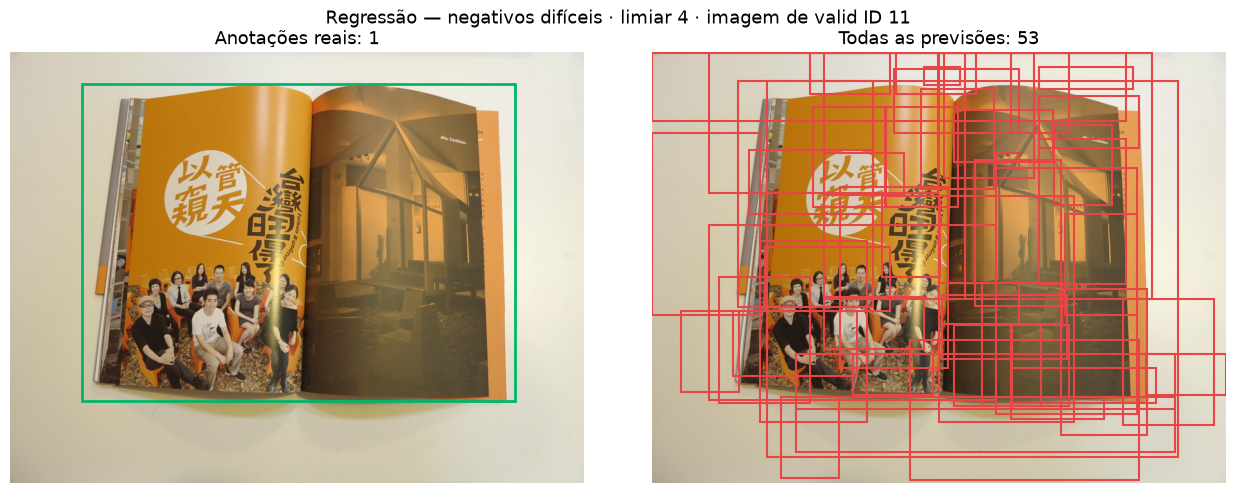

#### MLP — 30 negativos · limiar 0.495

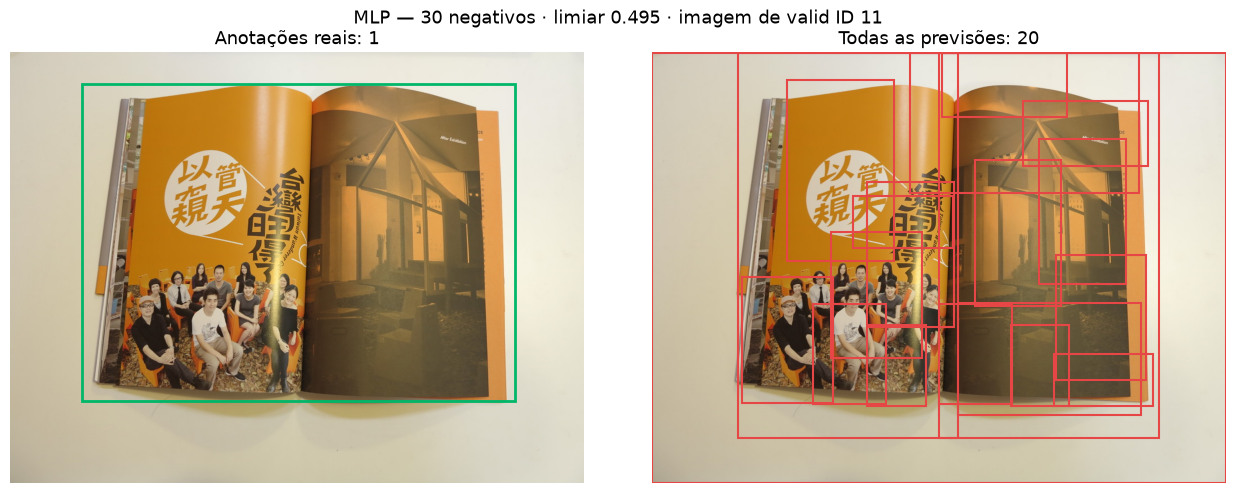

In [17]:
demo_record = valid_records[11]
demo_image = cv2.imread(str(demo_record.path))
if demo_image is None:
    raise ValueError(f"Imagem inválida: {demo_record.path}")

demo_targets = [
    clip_box(annotation.bbox, demo_image.shape[1], demo_image.shape[0])
    for annotation in demo_record.annotations
]
demo_targets = [box for box in demo_targets if box[2] > 0 and box[3] > 0]
demo_thresholds = {}
for name, model in models.items():
    selected = selections.get(name)
    if selected is not None:
        demo_thresholds[name] = selected.threshold
    else:
        demo_thresholds[name] = float(getattr(model, "score_threshold_", 0.0))
        display(
            Markdown(
                f"**{name}:** sem limiar elegível; exemplo no limiar de fallback "
                f"{demo_thresholds[name]:g}."
            )
        )

with threadpool_limits(limits=2):
    demo_predictions_by_model = detect_many(demo_image, models, demo_thresholds)

demo_rows = []
for name, predictions in demo_predictions_by_model.items():
    tp, fp, fn = count_matches(predictions, demo_targets, IOU_THRESHOLD)
    demo_rows.append([name, f"{demo_thresholds[name]:g}", tp, fp, fn, len(predictions)])

display(Markdown(f"**Mesma imagem de valid: ID {demo_record.id}.**"))
display(table(["Experimento", "Limiar", "TP", "FP", "FN", "Caixas"], demo_rows))

for index, (name, predictions) in enumerate(demo_predictions_by_model.items(), start=1):
    title = f"{name} · limiar {demo_thresholds[name]:g}"
    display(Markdown(f"#### {title}"))
    figures[f"deteccao_exemplo_valid_modelo_{index:02d}"] = detection_figure(
        demo_record, predictions, title
    )
    plt.show()

### 6.4. Avaliação final no conjunto de teste

Avaliação com as **22 imagens de test**, com 37 livros anotados, após definir os modelos e limiares em valid. Foram usados os quatro arquivos indicados no manifesto da rodada: referência, regularização, negativos difíceis e MLP.

**Nenhum limiar é escolhido em test.** Manteve-se os pesos, as janelas, o passo 32 e a IoU de correspondência ≥ 0,50. A recomendação continua sendo a configuração escolhida em valid; comparar resultados finais não autoriza reajustar o detector usando test.

Os resultados ficam em um relatório versionado. Se os arquivos, as imagens, as anotações e os parâmetros forem os mesmos, a célula lê o resultado já salvo, sem repetir a inferência. Alterações são detectadas por hashes; relatórios anteriores não são sobrescritos. Para avaliar novos treinos manuais, registre primeiro a seleção e os snapshots em um novo manifesto de valid.

In [18]:
if RETRAIN_MODELS or REEVALUATE_VALIDATION:
    raise ValueError(
        "Congele os novos snapshots e limiares em um manifesto de valid antes de avaliar test. "
        "Para os modelos já salvos, mantenha as opções iniciais em False."
    )

for entry in manifest["experiments"]:
    selected = selections.get(entry["label"])
    if selected is None or selected.threshold != entry["selected"]["threshold"]:
        raise ValueError(
            f"A seleção de {entry['label']} difere do protocolo salvo em valid. "
            "Registre um protocolo congelado antes de executar o teste final."
        )

test_report_path, test_report = evaluate_test_models(manifest, report_test_progress)
test_protocol = test_report["protocol"]
display(
    table(
        ["Experimento", "Arquivo congelado", "Limiar definido em valid"],
        [
            [snapshot["label"], f"{snapshot['name']}.pkl", f"{snapshot['threshold']:g}"]
            for snapshot in test_protocol["models"]
        ],
    )
)
print(f"Test: {test_protocol['images']} imagens, {test_protocol['annotations']} anotações")
print("Modelo recomendado previamente em valid:", test_protocol["recommended_model_from_valid"])
print("Relatório:", test_report_path)
print(f"Tempo da avaliação original: {test_report['elapsed_seconds']:.2f} s")

Experimento,Arquivo congelado,Limiar definido em valid
Regressão — 30 negativos,logistic_regression_003.pkl,10
"Regressão — C=0,01",logistic_regression_004.pkl,6
Regressão — negativos difíceis,logistic_regression_005.pkl,4
MLP — 30 negativos,mlp.pkl,0.495


Test: 22 imagens, 37 anotações
Modelo recomendado previamente em valid: logistic_regression_004
Relatório: C:\Users\ighor\Documents\repos\what-is-the-book\docs\results\test_evaluation_001.json
Tempo da avaliação original: 267.76 s


In [19]:
test_results = {
    result["label"]: ThresholdResult(result["threshold"], DetectionMetrics(**result["metrics"]))
    for result in test_report["results"]
}
display(
    table(
        ["Experimento", "Limiar", "TP", "FP", "FN", "Precisão", "Recall", "F1"],
        [
            [
                name,
                f"{result.threshold:g}",
                result.metrics.true_positives,
                result.metrics.false_positives,
                result.metrics.false_negatives,
                f"{result.metrics.precision:.2%}",
                f"{result.metrics.recall:.2%}",
                f"{result.metrics.f1_score:.4f}",
            ]
            for name, result in test_results.items()
        ],
    )
)

Experimento,Limiar,TP,FP,FN,Precisão,Recall,F1
Regressão — 30 negativos,10,19,499,18,3.67%,51.35%,0.0685
"Regressão — C=0,01",6,19,456,18,4.00%,51.35%,0.0742
Regressão — negativos difíceis,4,22,1560,15,1.39%,59.46%,0.0272
MLP — 30 negativos,0.495,19,501,18,3.65%,51.35%,0.0682


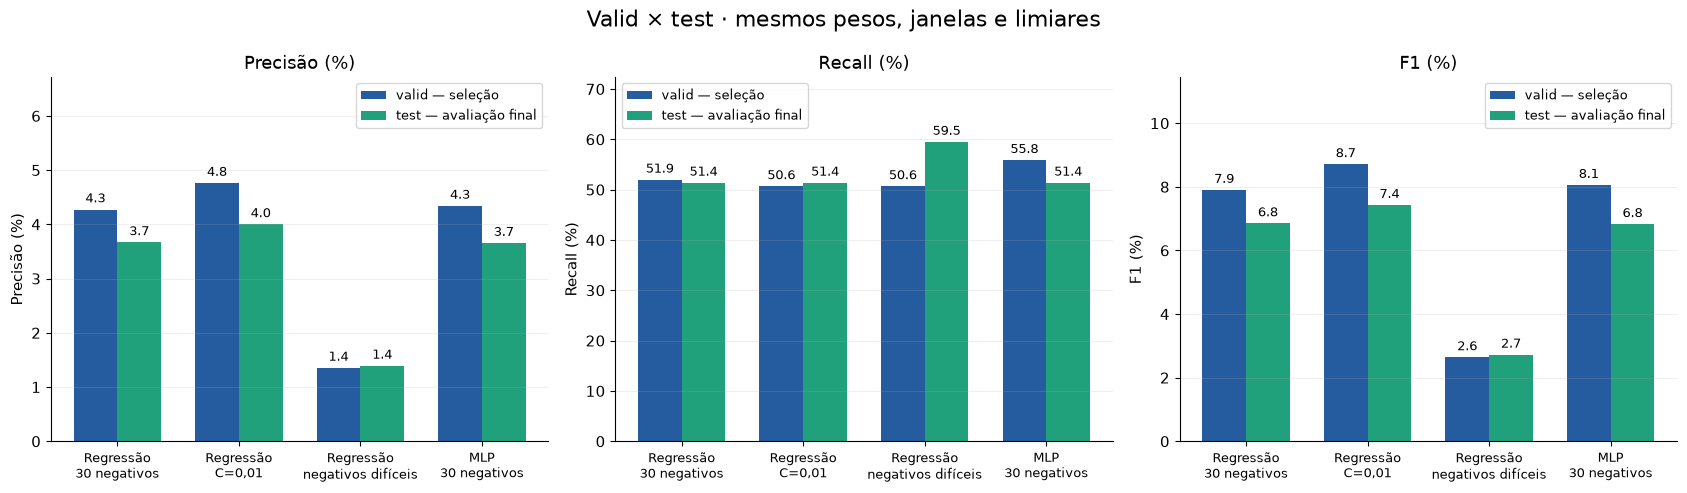

**Interpretação:** valid foi usado para escolher as configurações; test mede o resultado final com essas escolhas congeladas. Uma diferença entre as divisões deve ser relatada, não usada para procurar outro limiar em test. Os conjuntos são pequenos, portanto as métricas devem ser discutidas com essa limitação.

In [20]:
validation_results_at_frozen_thresholds = {name: selections[name] for name in test_results}
figures["comparacao_valid_test"] = validation_test_figure(
    validation_results_at_frozen_thresholds, test_results
)
plt.show()
display(
    Markdown(
        "**Interpretação:** valid foi usado para escolher as configurações; test mede o "
        "resultado final com essas escolhas congeladas. Uma diferença entre as divisões "
        "deve ser relatada, não usada para procurar outro limiar em test. Os conjuntos "
        "são pequenos, portanto as métricas devem ser discutidas com essa limitação."
    )
)

### 6.5. Conclusões
- HOG + janelas multiescala permite construir uma solução clássica, reproduzível e demonstrável.
- A precisão e o recall devem ser analisados juntos. Aumentar o limiar reduz caixas, mas pode perder livros.
- Regularização e negativos difíceis são hipóteses avaliadas separadamente; uma variante pior também é um resultado útil.
- O conjunto é pequeno, e a mineração depende de caixas completas. Texturas parecidas e deformação de proporções ainda dificultam a separação.
- As métricas de validação e de teste são apresentadas separadamente. A avaliação final em test usa somente os modelos e limiares congelados em valid, sem novos ajustes.
- Esta etapa localiza livros; reconhecimento do título pela capa está fora do escopo.

### Exportação opcional das figuras

As figuras estão disponíveis na memória para exportação. A opção fica desativada na apresentação; ao ativá-la, os PNGs recebem nomes versionados, sem substituir exportações anteriores. As imagens do dataset continuam locais e podem ter restrições próprias de uso.

In [21]:
EXPORT_FIGURES = False
if EXPORT_FIGURES:
    for name, figure in figures.items():
        print(export_figure(figure, name))
else:
    print("Exportação desativada. Use EXPORT_FIGURES=True para gerar PNGs para o artigo.")

Exportação desativada. Use EXPORT_FIGURES=True para gerar PNGs para o artigo.


### Referências e rastreabilidade

- [Documentação da Regressão Logística no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html): regularização e balanceamento.
- [Documentação do MLP no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html): arquitetura e parada antecipada.
- Histórico do projeto: `docs/historico-alteracoes.md`.
- Protocolo inicial preservado: `docs/baseline.md`.
- Resultados completos, manifesto e gráficos: `docs/results/`.

Para reproduzir a rodada limitada completa: `uv run python -m src.evaluation.run_precision`. Isso gera novas versões de modelos e relatórios. Para apresentar, mantenha as opções de treinamento e reavaliação em False.